MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 16.7669051	test: 16.8217715	best: 16.8217715 (0)	total: 17.4ms	remaining: 52.3s
100:	learn: 3.2626439	test: 3.3171527	best: 3.3171527 (100)	total: 1.08s	remaining: 31s
200:	learn: 1.2439659	test: 1.3008280	best: 1.3008280 (200)	total: 1.77s	remaining: 24.7s
300:	learn: 0.8064671	test: 0.8737733	best: 0.8737733 (300)	total: 2.43s	remaining: 21.8s
400:	learn: 0.6208104	test: 0.6907366	best: 0.6907366 (400)	total: 3.08s	remaining: 20s
500:	learn: 0.4911424	test: 0.5626871	best: 0.5626871 (500)	total: 3.75s	remaining: 18.7s
600:	learn: 0.4047553	test: 0.4785077	best: 0.4785077 (600)	total: 4.49s	remaining: 17.9s
700:	learn: 0.3508344	test: 0.4260458	best: 0.4260458 (700)	total: 5.21s	remaining: 17.1s
800:	learn: 0.3065980	test: 0.3822212	best: 0.3822212 (800)	total: 5.94s	remaining: 16.3s
900:	learn: 0.2785166	test: 0.3540900	best: 0.3540900 (900)	total: 6.65s	remaining: 15.5s
1000:	learn: 0.2551933	test: 0.3310465	best: 0.3310465 (1000)	total: 7.38s	remaining: 14.7s
1100:	learn:

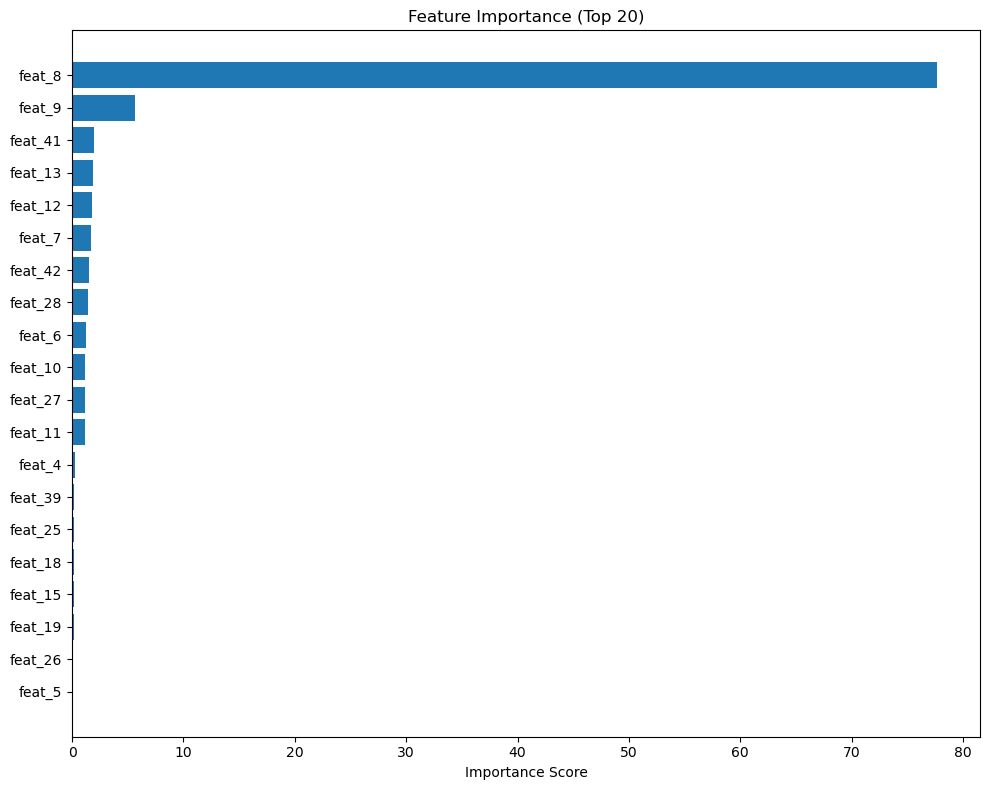

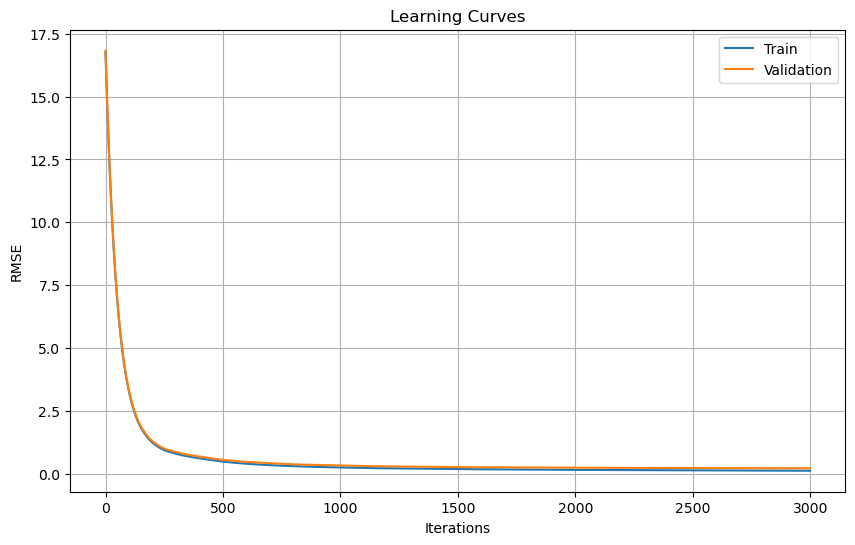

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import zscore, skew, kurtosis
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def add_features(X):
    sum_f = np.sum(X, axis=1, keepdims=True)
    mean_f = np.mean(X, axis=1, keepdims=True)
    std_f = np.std(X, axis=1, keepdims=True)

    interactions = np.hstack([
        X[:, i:i+1] * X[:, j:j+1]
        for i in range(4)
        for j in range(i+1, 4)
    ])

    return np.hstack([
        X,
        sum_f,
        mean_f,
        std_f,
        np.max(X, axis=1, keepdims=True),
        np.min(X, axis=1, keepdims=True),
        np.median(X, axis=1, keepdims=True),
        skew(X, axis=1, keepdims=True),
        kurtosis(X, axis=1, keepdims=True),
        np.sum(X > mean_f, axis=1, keepdims=True),
        np.log1p(np.abs(X[:, :4])),
        np.sqrt(np.abs(X[:, 4:8]) + 1e-6),
        interactions,
        X[:, :4] ** 2,
        X[:, 4:8] ** 3,
        (X[:, :4] + 1e-6) / (X[:, 4:8] + 1e-6),
        np.exp(0.01 * X[:, :4])
    ])

# Загрузка данных
X_train = np.loadtxt('data_pizdata/X_train.csv', delimiter=',')
y_train = np.loadtxt('data_pizdata/y_train.csv', delimiter=',')
X_train = np.delete(X_train, [4, 5, 6, 7], axis=1)

# Фильтрация выбросов
z_mask = (np.abs(zscore(X_train, axis=0)) < 3).all(axis=1)
X_train = X_train[z_mask]
y_train = y_train[z_mask]

# Добавление фичей
X_train_extended = add_features(X_train)

# Разделение на train/val
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_extended, y_train, test_size=0.2, random_state=42
)

# Трансформация данных
transformer = QuantileTransformer(output_distribution='normal')
X_train_transformed = transformer.fit_transform(X_train_split)
X_val_transformed = transformer.transform(X_val_split)

# Создаем пулы данных
train_pool = Pool(X_train_transformed, y_train_split)
val_pool = Pool(X_val_transformed, y_val_split)

# Параметры модели (используем RMSE вместо MSE)
params = {
    'iterations': 3000,
    'depth': 9,
    'learning_rate': 0.02,
    'l2_leaf_reg': 1.5,
    'random_strength': 0.3,
    'bagging_temperature': 0.5,
    'loss_function': 'RMSE',  # CatBoost не поддерживает MSE как loss!
    'eval_metric': 'RMSE',   # Но можем считать MSE отдельно
    'random_seed': 42,
    'allow_writing_files': False,
    'early_stopping_rounds': 150,
    'border_count': 128,
    'used_ram_limit': '4gb',
    'task_type': 'CPU'
}

# Инициализация модели
model = CatBoostRegressor(**params)

# Обучение
model.fit(
    train_pool,
    eval_set=val_pool,
    plot=True,
    verbose=100
)

# Расчет MSE вручную
train_pred = model.predict(X_train_transformed)
val_pred = model.predict(X_val_transformed)
train_mse = mean_squared_error(y_train_split, train_pred)
val_mse = mean_squared_error(y_val_split, val_pred)

print(f"\nTraining MSE: {train_mse:.4f}")
print(f"Validation MSE: {val_mse:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
feature_importance = model.get_feature_importance()
feature_names = [f'feat_{i}' for i in range(X_train_extended.shape[1])]
sorted_idx = np.argsort(feature_importance)[-20:]  # Топ-20 признаков

plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.title('Feature Importance (Top 20)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Визуализация кривых обучения
metrics = model.eval_metrics(train_pool, ['RMSE'])
val_metrics = model.eval_metrics(val_pool, ['RMSE'])

plt.figure(figsize=(10, 6))
plt.plot(metrics['RMSE'], label='Train')
plt.plot(val_metrics['RMSE'], label='Validation')
plt.title('Learning Curves')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

# Предсказание на тесте
X_test = np.delete(np.loadtxt('data_pizdata/X_test.csv', delimiter=','), [4,5,6,7], axis=1)
X_test_extended = add_features(X_test)
X_test_transformed = transformer.transform(X_test_extended)
predictions = model.predict(X_test_transformed)

# Сохранение
pd.DataFrame({'y': predictions, 'ID': range(len(predictions))}).to_csv('катбустер.csv', index=False)